# Tabular DL: S&P 500 Equity Option Analytics

GBM achieved marginal IC on the 5-day label (+0.0057) - a positive but small
improvement over linear's near-zero. TabM (Gorishniy et al., 2025) tests whether a
parameter-efficient neural ensemble captures higher-order feature interactions more
effectively than tree splits. Rather than an exotic architecture, TabM is a shared
MLP backbone with M rank-1 adapters that behave as a deep ensemble at the cost of a
single network - there is no attention mechanism. With 48 features spanning 6
families, averaging the ensemble members can smooth the noisy cross-family
interactions (e.g., IV term structure x VRP x momentum regime) that trees approximate
with many splits.

**Learning Objectives**:
- Test whether a rank-1 adapter MLP ensemble captures cross-family feature interactions in IV data
- Compare TabM configurations (small/medium/large) via walk-forward IC
- Assess whether TabM's higher validation IC is consistent across folds
- Generate backtesting-ready predictions for Ch16 strategy simulation

**Book Reference**: Chapter 12, Section 12.3 (Deep Learning Alternatives)

**Prerequisites**: `03_financial_features.py` (45 IV + equity features), `04_model_based_features.py` (3 GARCH features)

In [1]:
"""Tabular DL Grid Search - TabM via walk-forward CV."""

import sqlite3
import warnings

import plotly.graph_objects as go
import polars as pl
import torch
import yaml

import utils.style as style
from case_studies.utils.registry import build_training_spec, training_hash_from_spec
from case_studies.utils.tabular_dl import run_tabm_cv
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")
COLORS = style.COLORS

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
PRIMARY_LABEL = ""  # Read from setup.yaml if empty
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
BATCH_SIZE = 4096
MAX_FOLDS = 0

In [3]:
# Resolve config from setup.yaml
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]
    print(f"Label from setup.yaml: {PRIMARY_LABEL}")
else:
    print(f"Label override: {PRIMARY_LABEL}")

tdl_config = setup.get("modeling", {}).get("tabular_dl", {})
MODELS = tdl_config.get("models", ["tabm"])
DEVICE = tdl_config.get("device", "gpu")

include_tabpfn = "tabpfn" in MODELS

device_str = "cuda" if DEVICE == "gpu" and torch.cuda.is_available() else "cpu"
print(f"Case study: {CASE_STUDY_ID}")
print(f"Device: {device_str} | Models: {MODELS}")
print(f"Epochs: {N_EPOCHS} | Batch: {BATCH_SIZE}")

Label from setup.yaml: fwd_ret_5d
Case study: sp500_equity_option_analytics
Device: cuda | Models: ['tabm']
Epochs: 100 | Batch: 4096


## 1. Load Artifacts

Load pre-computed financial features (Ch8), temporal features (Ch9), labels,
and generate CV splits using the shared modeling infrastructure.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits
if MAX_FOLDS:
    splits = splits[:MAX_FOLDS]
n_features = len(feature_names)

print(f"Dataset: {len(dataset):,} rows × {n_features} features")
print(f"Label: {label_col} | Date: {date_col} | Entity: {entity_col}")
for s in splits:
    print(
        f"  Fold {s['fold']}: train {str(s['train_start'])[:10]}\u2192{str(s['train_end'])[:10]}  "
        f"val {str(s['val_start'])[:10]}\u2192{str(s['val_end'])[:10]}"
    )

Dataset: 527,968 rows × 48 features
Label: fwd_ret_5d | Date: timestamp | Entity: symbol
  Fold 0: train 2018-01-04→2019-12-18  val 2020-01-06→2020-12-23
  Fold 1: train 2017-01-05→2018-12-19  val 2019-01-07→2020-01-03


## 1b. Data Diagnostics

In [5]:
dataset_pd = dataset.to_pandas()

label_nans = dataset_pd[label_col].isna().sum()
feat_nan_rate = dataset_pd[feature_names].isna().mean().mean()
n_entities = dataset_pd[entity_col].nunique()

print(f"Entities: {n_entities}")
print(f"Label NaN: {label_nans:,} / {len(dataset_pd):,} ({label_nans / len(dataset_pd):.1%})")
print(f"Feature NaN rate: {feat_nan_rate:.1%}")

Entities: 630
Label NaN: 0 / 527,968 (0.0%)
Feature NaN rate: 22.4%


## 2. Build Grid

TabM configurations: small (64h×4m), medium (128h×8m), large (256h×16m).
Optionally includes TabPFN (foundation model, subsampled to 2K training rows).

In [6]:
tabdl_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "tabular_dl")

# Apply Papermill overrides to configs (test mode: fewer epochs)
for cfg in tabdl_configs:
    if cfg.get("n_epochs", 100) != N_EPOCHS:
        cfg["n_epochs"] = N_EPOCHS
    if cfg.get("batch_size", 4096) != BATCH_SIZE:
        cfg["batch_size"] = BATCH_SIZE

print(f"Grid: {len(tabdl_configs)} configs × {N_EPOCHS} epochs × {len(splits)} folds")
for cfg in tabdl_configs:
    name = cfg["config_name"]
    params = cfg.get("params", {})
    if name.startswith("tabpfn"):
        print(f"  {name:15s}  max_samples={params.get('max_samples', 2000)}")
    else:
        print(
            f"  {name:15s}  hidden={params['hidden_dim']}  "
            f"members={params['n_members']}  dropout={params['dropout']}"
        )

Grid: 3 configs × 100 epochs × 2 folds
  tabm_s           hidden=64  members=4  dropout=0.1
  tabm_m           hidden=128  members=8  dropout=0.1
  tabm_l           hidden=256  members=16  dropout=0.1


## 3. Run Tabular DL CV

Walk-forward training with IC evaluation at epoch checkpoints.

In [7]:
result = run_tabm_cv(
    dataset_pd,
    splits,
    feature_names=feature_names,
    label_col=label_col,
    date_col=date_col,
    entity_col=entity_col,
    configs=tabdl_configs,
    n_features=n_features,
    device=device_str,
    save_dir=CASE_DIR / "run_log" / "training" / "tabular_dl",
    register=True,
    force_retrain=FORCE_RETRAIN,
    prediction_split=PREDICTION_SPLIT,
    case_study=CASE_STUDY_ID,
    notebook="08_tabular_dl",
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
)

  SKIP tabm_s                     (complete (hash=56ab23e63262), split=validation)
  SKIP tabm_m                     (complete (hash=0d991d67544d), split=validation)
  SKIP tabm_l                     (complete (hash=63a874f42085), split=validation)
All configs already registered - rebuilding result from frozen registry.


In [8]:
# On a reproduce run every config already has a complete registry hash, so the sweep
# above SKIPs all of them and run_tabm_cv returns empty results (it only assembles a
# leaderboard for configs it retrains). Repopulate the leaderboard, learning curves,
# and per-fold IC from the stored prediction sets so the cells and figures below
# render the sweep without retraining.
def _load_tabm_results_from_registry(case_study, configs, label, split, n_folds):
    db_path = get_case_study_dir(case_study) / "run_log" / "registry.db"
    con = sqlite3.connect(db_path)
    try:
        grid, curve_rows = [], []
        for cfg in configs:
            spec = build_training_spec(
                cfg["family"],
                cfg["config_name"],
                label,
                n_folds=n_folds,
                n_epochs=cfg.get("n_epochs"),
            )
            thash = training_hash_from_spec(spec)
            rows = con.execute(
                "SELECT ps.checkpoint_value, pm.ic_mean, ps.prediction_hash "
                "FROM prediction_sets ps "
                "JOIN training_runs tr ON tr.training_hash = ps.training_hash "
                "JOIN prediction_metrics pm ON pm.prediction_hash = ps.prediction_hash "
                "WHERE ps.training_hash = ? AND ps.split = ? "
                "AND ps.created_at >= COALESCE(tr.started_at, tr.created_at) "
                "ORDER BY ps.checkpoint_value",
                (thash, split),
            ).fetchall()
            if not rows:
                continue
            elapsed = con.execute(
                "SELECT elapsed_s FROM training_runs WHERE training_hash = ?", (thash,)
            ).fetchone()
            for ckpt, ic_mean, _ in rows:
                curve_rows.append(
                    {"config": cfg["config_name"], "epoch": int(ckpt), "ic_mean": float(ic_mean)}
                )
            best = max(rows, key=lambda r: r[1])
            grid.append(
                {
                    "config_name": cfg["config_name"],
                    "best_epoch": int(best[0]),
                    "best_ic": float(best[1]),
                    "best_prediction_hash": best[2],
                    "elapsed_s": float(elapsed[0]) if elapsed and elapsed[0] is not None else 0.0,
                }
            )
        grid.sort(key=lambda r: r["best_ic"], reverse=True)
        best_row = grid[0] if grid else None
        fold_rows = []
        if best_row is not None:
            for fid, ic, n_ent in con.execute(
                "SELECT fold_id, ic, n_entities FROM fold_metrics "
                "WHERE prediction_hash = ? ORDER BY fold_id",
                (best_row["best_prediction_hash"],),
            ).fetchall():
                fold_rows.append(
                    {"fold_id": int(fid), "ic_mean": float(ic), "n_entities": int(n_ent or 0)}
                )
        return {
            "grid_results": grid,
            "best_config_name": best_row["config_name"] if best_row else None,
            "best_epoch": best_row["best_epoch"] if best_row else 0,
            "best_ic": best_row["best_ic"] if best_row else float("nan"),
            "predictions": pl.DataFrame(),
            "all_predictions": pl.DataFrame(),
            "fold_metrics": pl.DataFrame(fold_rows),
            "all_learning_curves": pl.DataFrame(curve_rows),
            "training_log": pl.DataFrame(),
        }
    finally:
        con.close()


if not result["grid_results"]:
    print("All configs SKIP'd - reloading the stored leaderboard from the registry.")
    result = _load_tabm_results_from_registry(
        CASE_STUDY_ID, tabdl_configs, label_col, PREDICTION_SPLIT, len(splits)
    )

## 4. Grid Results

In [9]:
grid_results = result["grid_results"]
best_name = result["best_config_name"]
best_epoch = result["best_epoch"]
best_ic = result["best_ic"]

print(f"{'Config':15s} {'Best Epoch':>10s} {'Peak IC':>10s} {'Time':>8s}")
print(f"{'-' * 48}")
for r in grid_results:
    marker = " *" if r["config_name"] == best_name else ""
    print(
        f"{r['config_name']:15s} {r['best_epoch']:10d} {r['best_ic']:+10.4f} "
        f"{r['elapsed_s']:7.1f}s{marker}"
    )
print(f"{'-' * 48}")
print(f"Best: {best_name} @ epoch {best_epoch} (IC={best_ic:+.4f})")

Config          Best Epoch    Peak IC     Time
------------------------------------------------
tabm_s                  75    +0.0157     0.0s *
tabm_m                  50    +0.0143     0.0s
tabm_l                  50    +0.0005     0.0s
------------------------------------------------
Best: tabm_s @ epoch 75 (IC=+0.0157)


### Validation IC by configuration

Peak validation IC for each TabM size. The smallest model leads and IC falls as
capacity grows: with only two folds and 48 features, the larger ensembles overfit
rather than exploit their extra capacity.

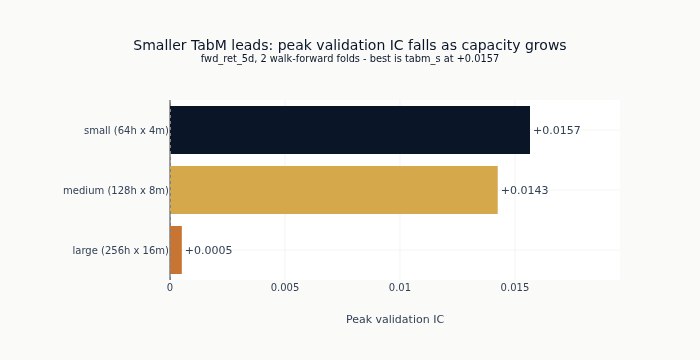

In [10]:
SIZE_COLOR = {"tabm_s": COLORS["blue"], "tabm_m": COLORS["amber"], "tabm_l": COLORS["copper"]}
SIZE_LABEL = {
    "tabm_s": "small (64h x 4m)",
    "tabm_m": "medium (128h x 8m)",
    "tabm_l": "large (256h x 16m)",
}

order = [r["config_name"] for r in grid_results]  # already sorted best-first
fig = go.Figure()
fig.add_trace(
    go.Bar(
        y=[SIZE_LABEL.get(r["config_name"], r["config_name"]) for r in grid_results],
        x=[r["best_ic"] for r in grid_results],
        orientation="h",
        marker_color=[SIZE_COLOR.get(r["config_name"], COLORS["blue"]) for r in grid_results],
        text=[f"{r['best_ic']:+.4f}" for r in grid_results],
        textposition="outside",
    )
)
fig.add_vline(x=0.0, line=dict(color="gray", dash="dot"))
# categoryarray runs bottom->top, so reverse the best-first order to put the winner on top.
fig.update_yaxes(
    type="category",
    categoryorder="array",
    categoryarray=list(reversed([SIZE_LABEL.get(c, c) for c in order])),
)
fig.update_xaxes(range=[0, max(r["best_ic"] for r in grid_results) * 1.25])
fig.update_layout(
    title_text="Smaller TabM leads: peak validation IC falls as capacity grows"
    f"<br><sup>fwd_ret_5d, 2 walk-forward folds - best is {best_name} at {best_ic:+.4f}</sup>",
    xaxis_title="Peak validation IC",
    height=360,
    margin=dict(l=170),
    showlegend=False,
)
fig.show()

### Grid Interpretation

The small configuration leads at +0.0157, followed closely by the medium model at
+0.0143; the large model falls to +0.0005. Both validation folds are positive for
the winner, but the gap between model sizes and the short two-fold history make the
ranking fragile.

## 5. Learning Curves

Validation IC at every 25-epoch checkpoint. The winning small model peaks at epoch
75, while the medium and large configurations peak at epoch 50. With only two folds,
the checkpoint ranking should be read as suggestive rather than stable.

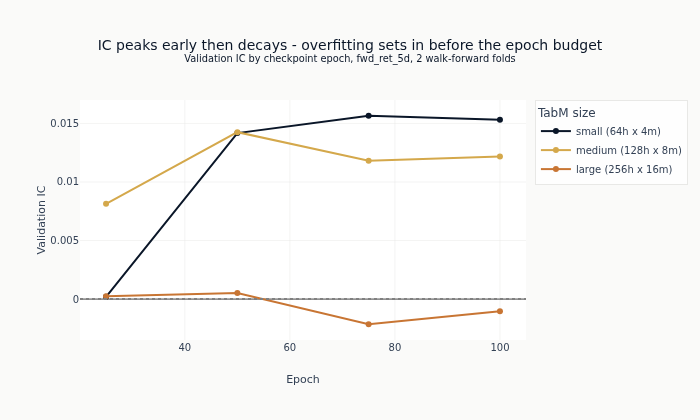

In [11]:
curves = result["all_learning_curves"]
fig2 = go.Figure()
if curves.height > 0:
    for cfg_name in order:
        cdata = curves.filter(pl.col("config") == cfg_name).sort("epoch")
        if cdata.height == 0:
            continue
        fig2.add_trace(
            go.Scatter(
                x=cdata["epoch"].to_list(),
                y=cdata["ic_mean"].to_list(),
                mode="lines+markers",
                name=SIZE_LABEL.get(cfg_name, cfg_name),
                line=dict(color=SIZE_COLOR.get(cfg_name, COLORS["blue"])),
            )
        )
    fig2.add_hline(y=0.0, line=dict(color="gray", dash="dot"))
    fig2.update_layout(
        title_text="IC peaks early then decays - overfitting sets in before the epoch budget"
        "<br><sup>Validation IC by checkpoint epoch, fwd_ret_5d, 2 walk-forward folds</sup>",
        xaxis_title="Epoch",
        yaxis_title="Validation IC",
        height=420,
        legend_title_text="TabM size",
    )
fig2.show()

## 6. Fold Metrics

In [12]:
fold_metrics = result["fold_metrics"]
if fold_metrics.height > 0:
    print(f"\nPer-fold IC ({best_name}):")
    for row in fold_metrics.iter_rows(named=True):
        print(f"  Fold {row['fold_id']}: IC={row['ic_mean']:+.4f}  symbols={row['n_entities']:,}")
    mean_ic = fold_metrics["ic_mean"].mean()
    print(f"\n  Mean IC: {mean_ic:+.4f}")


Per-fold IC (tabm_s):
  Fold 0: IC=+0.0223  symbols=522
  Fold 1: IC=+0.0090  symbols=530

  Mean IC: +0.0157


## 7. Registered Artifacts

`run_tabm_cv()` registers predictions and per-fold metrics to the case-study registry
during training. On a reproduce run the configs SKIP, so the leaderboard, learning
curves, and fold metrics above are read back from the registry; the prediction
parquets that Ch16 consumes remain on disk under `run_log/training/tabular_dl/`.

In [13]:
if result["predictions"].height > 0:
    print(f"predictions.parquet:     {result['predictions'].height:,} rows")
    print(f"all_predictions.parquet: {result['all_predictions'].height:,} rows")
else:
    print("Predictions previously registered (reproduce run - see run_log/training/tabular_dl/).")
if curves.height > 0:
    print(f"learning_curves:         {curves.height:,} checkpoint rows")
if fold_metrics.height > 0:
    print(f"fold_metrics:            {fold_metrics.height} folds")

val_ic_mean = float(fold_metrics["ic_mean"].mean()) if fold_metrics.height > 0 else None

predictions.parquet:     210,739 rows
all_predictions.parquet: 2,528,868 rows
learning_curves:         12 checkpoint rows
fold_metrics:            2 folds


## 8. Summary

In [14]:
print(f"\n{'=' * 60}")
print(f"Tabular DL Grid Search: {CASE_STUDY_ID}")
print(f"{'=' * 60}")
print(f"Features: {n_features}  |  Folds: {len(splits)}  |  Label: {label_col}")
print(f"Device: {device_str}  |  Epochs: {N_EPOCHS}")
print(f"Grid: {len(tabdl_configs)} configs ({', '.join(MODELS)})")
print(f"{'-' * 60}")
print(f"Best config: {best_name} @ epoch {best_epoch}")
print(f"Validation IC (cross-sectional): {best_ic:+.4f}")
if val_ic_mean is not None:
    print(f"Mean fold IC: {val_ic_mean:+.4f}")


Tabular DL Grid Search: sp500_equity_option_analytics
Features: 48  |  Folds: 2  |  Label: fwd_ret_5d
Device: cuda  |  Epochs: 100
Grid: 3 configs (tabm)
------------------------------------------------------------
Best config: tabm_s @ epoch 75
Validation IC (cross-sectional): +0.0157
Mean fold IC: +0.0157


## Key Takeaways

1. **The small TabM leads the grid at +0.0157**: both validation folds are positive,
   at +0.0223 and +0.0090, but the two-fold history limits confidence in the ranking
2. **Capacity does not help**: the smallest TabM (64 hidden, 4 members) wins while the
   medium model is close at +0.0143 and the large model falls to +0.0005
3. **Checkpoint selection remains fragile**: the winner peaks at epoch 75, whereas
   the other configurations peak at epoch 50
4. **The result is model-sensitive**: the large configuration's near-zero IC shows
   that extra capacity does not reliably extract more signal from this feature set

**Next**: `09_dl_lstm.py` tests whether temporal structure (60-day IV evolution)
adds value beyond the flat feature snapshot that TabM uses.